# 14 — Prompt refinement (version-aware) + PIT-vs-non-PIT contrast (openai/gpt-oss-20b)

Excel storyboard S4 (recall line) + S5 on top of nb13's committed v1 stream (task 4.2; R1.2, R5, R7):

- R5: a second prompt version (v2 = the SAME anonymized PIT renderer output + ONE appended
  output-discipline line) is run over the SAME 72-rebalance stream; per-version `p_memorized`
  distributions (version-aware, R1.2), factor stability, parse rates and head-to-head deltas feed an
  accept-gate (adopt v2 only at no-greater contamination and no-worse metrics, R5.4); prior
  version artifacts are preserved either way (R5.5).
- R7: the **non-PIT DIAGNOSTIC CONTROL**, the same renderer with `identifying=True`
  (real tickers + as-of date + raw levels — token-identical except the additions, R7.6) over the SAME
  72 dates, through the SAME guard and blend. **The non-PIT line is a diagnostic control and is NEVER
  the deployable portfolio (R7.4)** — it exists only to measure the contamination premium
  (non-PIT − PIT) with a paired effect size over the full stream (R7.2/7.5).
- S5: `compute_ssr` (Sharpe Stability Ratio, Newey-West HAC, Andrews bandwidth) on the PIT
  guarded line, the non-PIT diagnostic line, and the recall-minus-no-recall return DIFFERENTIAL:
  luck-vs-skill stated with robust inference. Any non-PIT edge is lookahead/recall bias, never
  attainable skill (R7.5).

nb13's v1 artifacts are REUSED verbatim (zero new NIM calls for v1); success stays NON-PREDICTIVE
throughout (R6.4) — no forecast-accuracy claim anywhere.

In [1]:
import json
import math
import os
import re
import sys
import warnings
from datetime import date
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from dotenv import load_dotenv

import macro_framework as mf
from macro_framework import factor_scoring as fs
from macro_framework.ssr import compute_ssr
from recall_guard import NvidiaLM
from recall_guard.core.nvidia_lm import generate_many

load_dotenv(REPO / ".env")
pd.set_option("display.width", 200)

DATA = REPO / "data"
INIT_CASH = 10_000.0
SIM_START = "2019-01-01"
SIM_END = "2024-12-31"
LOOKBACK_DAYS = 756
TILT = 0.30  # nb09 final blend = 0.7*HRP + 0.3*BL

# Selected model + persisted production calibrator (research.md 2026-07-03): gpt-oss-20b,
# TRUE cutoff 2024-06-01, holdout_auc 0.9668, is_weak False.
NIM_MODEL = "openai/gpt-oss-20b"
CUTOFF = date(2024, 6, 1)
SLUG = NIM_MODEL.replace("/", "_")
CAL_DIR = DATA / f"factor_calibrator_{SLUG}"
TIMEOUT_S = 120.0  # reasoning model; NvidiaLM's 15 s default is too tight
MAX_WORKERS = 6

nvidia_key = (os.environ.get("NVIDIA_API_KEY") or "").strip()
if not nvidia_key:
    raise RuntimeError("NVIDIA_API_KEY not set in .env — required for the NIM generate/score paths")

spec = pd.read_parquet(DATA / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
asset_map = mf.AssetMap.default()
PANEL_Z_COLS = ["cpi_yoy_z", "t10y2y_z", "hy_oas_z"]
PANEL_RAW_COLS = ["cpi_yoy", "t10y2y", "hy_oas"]  # the renderer's raw_levels keys (module _RAW_TO_Z)

lm = NvidiaLM(api_key=nvidia_key, model=NIM_MODEL, timeout_s=TIMEOUT_S)
print("SYMBOLS:", SYMBOLS)
print("NIM model:", NIM_MODEL, "| cutoff:", CUTOFF.isoformat(), "| timeout_s:", TIMEOUT_S)

SYMBOLS: ['SWDA.L', 'XLK', 'IAU', 'BIL']
NIM model: openai/gpt-oss-20b | cutoff: 2024-06-01 | timeout_s: 120.0


## 1. Prices + macro panel (yfinance in-cell; the project price DB is absent here)

In [2]:
macro_panel = pd.read_parquet(DATA / "macro_panel_monthly.parquet")
macro_panel.index = pd.DatetimeIndex(macro_panel.index)
print("macro panel:", macro_panel.shape, "|", macro_panel.index.min().date(), "->", macro_panel.index.max().date())

# Daily prices (DB unavailable here -> public source; additive, no module change). Mirrors nb11/nb13.
def _fetch_prices() -> pd.DataFrame:
    import time
    import yfinance as yf
    want = SYMBOLS + ["SPY"]
    last_exc = None
    for attempt in range(6):
        try:
            raw = yf.download(want, start="2014-01-01", end=SIM_END,
                              auto_adjust=True, progress=False, threads=False)
            close = raw["Close"] if ("Close" in raw.columns.get_level_values(0)) else raw
            close = close[want].copy()
            close.index = pd.DatetimeIndex(close.index)
            if close[SYMBOLS].dropna(how="all").shape[0] > 1000:
                return close
        except Exception as exc:  # noqa: BLE001
            last_exc = exc
        time.sleep(8)
    raise RuntimeError(f"price fetch failed after retries: {last_exc!r}")

prices = _fetch_prices()
rebalance_dates = mf.monthly_rebalance_dates(prices[SYMBOLS], start=SIM_START, end=SIM_END)
all_returns = prices[SYMBOLS].pct_change()
print("prices:", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())
print(f"{len(rebalance_dates)} monthly rebalances  {rebalance_dates[0].date()} -> {rebalance_dates[-1].date()}")

macro panel: (196, 6) | 2010-01-31 -> 2026-04-30


prices: (2828, 5) | 2014-01-02 -> 2024-12-30
72 monthly rebalances  2019-01-02 -> 2024-12-02


## 2. Reuse nb13's v1 stream (zero new NIM calls for v1)

The incumbent v1 = nb13's anonymized PIT renderer output; its loadings, `p_memorized` scores,
targets and equity are read back from the persisted `*_v1` artifacts and NEVER rewritten (R5.5/R6.1).
The PIT prompt stream is re-rendered deterministically (same renderer, same inputs) purely as the
replay/pairing key.

In [3]:
loadings_v1 = pd.read_parquet(DATA / "factor_loadings_v1.parquet")
scores_v1 = pd.read_parquet(DATA / "factor_scores_v1.parquet")
targets_v1 = pd.read_parquet(DATA / "factor_targets_v1.parquet")
equity_v1 = pd.read_parquet(DATA / "factor_equity_v1.parquet")["value"]
stability_v1 = json.loads((DATA / "factor_stability_v1.json").read_text())

# The factor prompt's asset snapshot matches the calibration corpus exactly (pseudo id + category).
FACTOR_SNAPSHOT = [
    {"id": pseudo, "category": cat} for pseudo, cat in sorted(asset_map.categories.items())
]


def _panel_row_asof(rb: pd.Timestamp):
    """Last macro-panel row strictly before rb -> (z-scored state, raw levels) or (None, None)."""
    avail = macro_panel.dropna(subset=PANEL_Z_COLS)
    asof = avail[avail.index < rb]
    if asof.empty:
        return None, None
    row = asof.iloc[-1]
    return row[PANEL_Z_COLS].to_dict(), {c: float(row[c]) for c in PANEL_RAW_COLS if c in row}


factor_meta = []  # (rb, macro_state, raw_levels, pit_prompt) — the SAME PIT stream as nb13
for rb in rebalance_dates:
    macro_state, raw_levels = _panel_row_asof(rb)
    if macro_state is None:
        continue
    factor_meta.append((rb, macro_state, raw_levels,
                        fs.render_regime_loadings_prompt(macro_state, FACTOR_SNAPSHOT)))

pit_prompts = [p for _, _, _, p in factor_meta]
meta_dates = [rb for rb, _, _, _ in factor_meta]
assert list(loadings_v1.index) == meta_dates, "PIT stream drifted from the persisted v1 artifacts"
assert list(scores_v1.index) == meta_dates
print(f"PIT stream: {len(pit_prompts)} rebalance prompts — aligned with factor_*_v1 artifacts")

# v1 FactorScores replayed from the persisted parquet (R1.1 scores of the v1 prompts; no NIM call).
score_v1_by_prompt = {}
for (rb, _, _, prompt) in factor_meta:
    pm = scores_v1.loc[rb, "p_memorized"]
    score_v1_by_prompt[prompt] = fs.FactorScore(
        p_memorized=(None if pd.isna(pm) else float(pm)), parse_ok=not pd.isna(pm),
        fail_reason=(scores_v1.loc[rb, "fail_reason"] if pd.isna(pm) else None))

pm_v1 = scores_v1["p_memorized"].dropna().astype(float)
parse_rate_v1 = float(loadings_v1["parse_ok"].mean())
print(f"v1 (incumbent): p_memorized mean={pm_v1.mean():.4f} median={pm_v1.median():.4f} "
      f"| parse rate={parse_rate_v1:.3f} | stability mean_mac={stability_v1['mean_mac']:.4f}")


def lm_factory(key: str, model: str) -> NvidiaLM:
    return NvidiaLM(api_key=key, model=model, timeout_s=TIMEOUT_S)


scorer = fs.FactorScorer.load(CAL_DIR, api_key=nvidia_key, lm_factory=lm_factory)
print(f"FactorScorer loaded from {CAL_DIR.name}: holdout_auc={scorer.holdout_auc:.4f}  is_weak={scorer.is_weak}")
assert scorer.is_weak is False, "calibrator weak -> guard would pass through (R4.3); expected strong per research.md"


def _generate_big(prompts: list, max_tokens: int = 2048) -> list:
    """Parallel generate at a larger completion budget (the nb13 reasoning-truncation retry)."""
    from concurrent.futures import ThreadPoolExecutor

    def _one(p):
        try:
            return lm.generate(p, max_tokens=max_tokens)
        except Exception as exc:  # noqa: BLE001 -- keep the failure recorded as a failed row
            return exc

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        return list(ex.map(_one, prompts))


def _retry_failed(replies: list, prompts: list) -> list:
    """Resilience: one batched bigger-budget retry per failed generate."""
    out = list(replies)
    bad = [i for i, r in enumerate(out) if isinstance(r, BaseException)]
    if bad:
        for i, r in zip(bad, _generate_big([prompts[i] for i in bad])):
            out[i] = r
    return out


def _reply_text(reply) -> str:
    return "" if isinstance(reply, BaseException) else reply.content

PIT stream: 72 rebalance prompts — aligned with factor_*_v1 artifacts
v1 (incumbent): p_memorized mean=0.2361 median=0.2085 | parse rate=0.986 | stability mean_mac=0.3878
FactorScorer loaded from factor_calibrator_openai_gpt-oss-20b: holdout_auc=0.9668  is_weak=False


## R5 — Prompt version v2 over the SAME PIT stream

v2 = the SAME anonymized renderer output + ONE appended output-discipline line. The addition is
PIT-safe (no identity, no date, no raw level — the point-in-time discipline is untouched) and purely
output-formatting, so any `p_memorized` difference is attributable to the version's own prompt
content (R1.2). v2 is generated → `parse_loadings` → scored on the SAME v2 prompt, over the same
72 dates; artifacts are persisted under `_v2` names, never overwriting v1 (R5.5).

In [4]:
PROMPT_V2_SUFFIX = "Respond with ONLY the JSON object — no other text."
v2_prompts = [p + "\n" + PROMPT_V2_SUFFIX for p in pit_prompts]
assert all(v2.startswith(pit) for v2, pit in zip(v2_prompts, pit_prompts))
print("v2 = v1 prompt + one output-discipline line (PIT-safe, version-tagged)")

v2_replies = _retry_failed(generate_many(lm, v2_prompts, max_workers=MAX_WORKERS), v2_prompts)
texts_v2 = [_reply_text(r) for r in v2_replies]
parsed_v2 = [fs.parse_loadings(t, rb) for (rb, _, _, _), t in zip(factor_meta, texts_v2)]

# Format-retry (the nb13 pattern): ONE batched max_tokens=2048 regeneration for any reply that did
# not yield the full five-axis vector; a repeat failure stays a failed row (module fallbacks apply).
_bad = [i for i, rl in enumerate(parsed_v2) if rl is None]
if _bad:
    for i, r in zip(_bad, _generate_big([v2_prompts[i] for i in _bad])):
        texts_v2[i] = _reply_text(r)
        parsed_v2[i] = fs.parse_loadings(texts_v2[i], factor_meta[i][0])
    print(f"format-retried {len(_bad)} v2 loadings replies at max_tokens=2048; "
          f"still unparsed: {sum(1 for i in _bad if parsed_v2[i] is None)}")

reply_v2_by_pit_prompt = {pit: t for pit, t in zip(pit_prompts, texts_v2)}
load_rows = []
for (rb, _, _, _), rl in zip(factor_meta, parsed_v2):
    row = {"date": rb, "parse_ok": rl is not None, "prompt_version": "v2"}
    for axis in fs.MACRO_AXES:
        row[axis] = rl.loadings[axis] if rl is not None else float("nan")
    load_rows.append(row)

loadings_v2_df = pd.DataFrame(load_rows).set_index("date")
loadings_v2_path = DATA / "factor_loadings_v2.parquet"
loadings_v2_df.to_parquet(loadings_v2_path)
parse_rate_v2 = float(loadings_v2_df["parse_ok"].mean())
print(f"parsed v2 loadings: {int(loadings_v2_df['parse_ok'].sum())}/{len(loadings_v2_df)} "
      f"-> wrote {loadings_v2_path.name}")

v2 = v1 prompt + one output-discipline line (PIT-safe, version-tagged)


format-retried 40 v2 loadings replies at max_tokens=2048; still unparsed: 0
parsed v2 loadings: 72/72 -> wrote factor_loadings_v2.parquet


wrote factor_scores_v2.parquet  scored ok: 72/72
per-version p_memorized (R1.2 — the versions DO differ):
  v1: mean=0.2361 median=0.2085 p90=0.5183
  v2: mean=0.2709 median=0.2993 p90=0.5537
factor stability: v1 mean_std=0.5437 mean_mac=0.3878 | v2 mean_std=0.5258 mean_mac=0.4063
parse rates: v1=0.986  v2=1.000


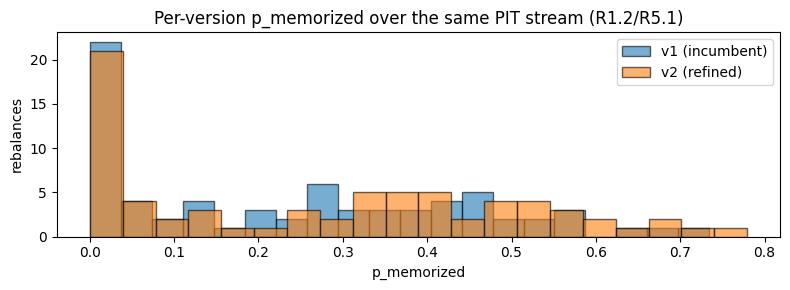

In [5]:
# Score v2 on the SAME v2 prompt (version-aware, R1.1/R1.2); one individual retry per failure.
v2_scores = list(scorer.score_many(v2_prompts, max_workers=MAX_WORKERS))
for i, sc in enumerate(v2_scores):
    if sc.p_memorized is None:
        v2_scores[i] = scorer.score(v2_prompts[i])

score_v2_by_pit_prompt = {pit: sc for pit, sc in zip(pit_prompts, v2_scores)}
scores_v2_df = pd.DataFrame({
    "date": meta_dates,
    "p_memorized": [sc.p_memorized for sc in v2_scores],
    "fail_reason": [sc.fail_reason for sc in v2_scores],
    "prompt_version": "v2",
}).set_index("date")
scores_v2_path = DATA / "factor_scores_v2.parquet"
scores_v2_df.to_parquet(scores_v2_path)

pm_v2 = scores_v2_df["p_memorized"].dropna().astype(float)
print(f"wrote {scores_v2_path.name}  scored ok: {len(pm_v2)}/{len(scores_v2_df)}")
print(f"per-version p_memorized (R1.2 — the versions DO differ):")
print(f"  v1: mean={pm_v1.mean():.4f} median={pm_v1.median():.4f} p90={pm_v1.quantile(0.9):.4f}")
print(f"  v2: mean={pm_v2.mean():.4f} median={pm_v2.median():.4f} p90={pm_v2.quantile(0.9):.4f}")

# Per-version factor stability (R5.2). v1 comes from its committed artifact; v2 is computed here.
stability_v2 = fs.factor_stability({rb: rl for (rb, _, _, _), rl in zip(factor_meta, parsed_v2)
                                    if rl is not None})
stability_v2_path = DATA / "factor_stability_v2.json"
stability_v2_path.write_text(json.dumps(stability_v2, indent=2, sort_keys=True))
print(f"factor stability: v1 mean_std={stability_v1['mean_std']:.4f} mean_mac={stability_v1['mean_mac']:.4f} "
      f"| v2 mean_std={stability_v2['mean_std']:.4f} mean_mac={stability_v2['mean_mac']:.4f}")
print(f"parse rates: v1={parse_rate_v1:.3f}  v2={parse_rate_v2:.3f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pm_v1, bins=20, alpha=0.6, label="v1 (incumbent)", edgecolor="black")
ax.hist(pm_v2, bins=20, alpha=0.6, label="v2 (refined)", edgecolor="black")
ax.set_title("Per-version p_memorized over the same PIT stream (R1.2/R5.1)")
ax.set_xlabel("p_memorized")
ax.set_ylabel("rebalances")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Variant lines through the SAME pipeline (walk-forward + vectorbt)

The replay infrastructure mirrors nb13's S4 exactly: `make_factor_weight_fn` composes renderer →
loadings → parse → tilt-as-exposure → recall-guarded discount → the UNCHANGED `views_to_bl`; nb09's
existing HRP-CVaR{BIL: 25%} base + BL(`Utility`) posterior at the 0.7/0.3 blend is injected via
`combine`. Replies and scores are replayed per variant (keyed on the internally rendered PIT prompt),
so the walk-forward itself is network-free.

In [6]:
class _ReplayScorer:
    """Replay scorer exposing the exact surface factor_rebalance / the contrast use
    (is_weak + score + score_many), backed by pre-computed FactorScores keyed on the
    prompt string — no NIM call. Unseen prompts degrade to unscored (R4.3 passthrough)."""

    is_weak = False  # the loaded calibrator is strong (asserted above)

    def __init__(self, by_prompt: dict) -> None:
        self._by = dict(by_prompt)

    def score(self, prompt: str):
        sc = self._by.get(prompt)
        if sc is None:
            return fs.FactorScore(p_memorized=None, parse_ok=False, fail_reason="not_pre_scored")
        return sc

    def score_many(self, prompts, *, max_workers: int = 8):
        return [self.score(p) for p in prompts]


bl_agent = mf.LlmMacroAgent(asset_map=asset_map)  # purely for its UNCHANGED views_to_bl


def build_inputs(ctx):
    """Walk-forward ctx -> (macro_state, asset_snapshot, as_of, raw_levels) for factor_rebalance."""
    mz = ctx["macro_panel"][PANEL_Z_COLS].dropna()
    macro_state = mz.iloc[-1].to_dict()  # ctx macro_panel is already sliced strictly-before rb
    return macro_state, FACTOR_SNAPSHOT, ctx["rebalance_date"], None


def combine(ctx, P, Q):
    """nb09's allocation, injected UNCHANGED: HRP-CVaR base (BIL pinned 25%) + BL posterior, 0.7/0.3 blend."""
    returns_hist = ctx["returns"]
    w_hrp = mf.hrp_cvar_weights_with_fixed(returns_hist, {"BIL": 0.25})
    if P is None:
        return w_hrp
    try:
        w_bl = mf.bl_mv_weights(returns_hist, prior_weights=w_hrp, P=P, Q=Q, obj="Utility")
    except Exception:  # noqa: BLE001 -- BL can fail on degenerate inputs; fall back to base
        return w_hrp
    w = (1.0 - TILT) * w_hrp + TILT * w_bl
    return w / w.sum()


def run_variant_line(name: str, reply_by_pit_prompt: dict, score_by_pit_prompt: dict):
    """One variant through the SAME pipeline: weight_fn -> walk-forward targets -> vectorbt sim
    + the nb13-style per-rebalance decision log. Replay-backed: zero NIM calls in here."""
    replay = _ReplayScorer(score_by_pit_prompt)

    def gen(prompt: str) -> str:
        return reply_by_pit_prompt.get(prompt, "")

    weight_fn = fs.make_factor_weight_fn(
        generate_loadings=gen, scorer=replay, agent=bl_agent,
        build_inputs=build_inputs, combine=combine)
    targets = mf.build_walk_forward_targets(
        prices[SYMBOLS], rebalance_dates=rebalance_dates,
        weight_fns={name: weight_fn}, macro_panel=macro_panel,
        lookback_days=LOOKBACK_DAYS)[name]
    pf = mf.run_rebalance_sim(prices[SYMBOLS], targets, init_cash=INIT_CASH)

    dlog = {"p_memorized": {}, "parse_ok": {}, "steered": {}, "conviction": {},
            "loadings": {}, "views": {}}
    for rb in rebalance_dates:
        try:
            macro_hist = macro_panel.loc[macro_panel.index < rb]
            price_hist = prices[SYMBOLS].loc[prices.index < rb].tail(LOOKBACK_DAYS)
            ret_hist = all_returns.loc[all_returns.index < rb].tail(LOOKBACK_DAYS).dropna(how="any")
            if macro_hist.empty or price_hist.shape[0] < 60 or ret_hist.shape[0] < 60:
                continue
            ctx = {"rebalance_date": rb, "prices": price_hist, "returns": ret_hist,
                   "macro_panel": macro_hist}
            macro_state, snap, as_of, raw_levels = build_inputs(ctx)
            dec = fs.factor_rebalance(
                generate_loadings=gen, scorer=replay, agent=bl_agent,
                macro_state=macro_state, asset_snapshot=snap, real_symbols=SYMBOLS, as_of=as_of)
            dlog["p_memorized"][rb] = dec.p_memorized
            dlog["parse_ok"][rb] = bool(dec.parse_ok)
            dlog["steered"][rb] = bool(dec.steered)
            dlog["conviction"][rb] = float(dec.views[0].confidence) if dec.views else None
            dlog["loadings"][rb] = dict(dec.loadings.loadings) if dec.loadings is not None else None
            dlog["views"][rb] = [v.to_dict() for v in dec.views]
        except Exception as exc:  # noqa: BLE001 -- per-date resilience: record, never crash the stream
            dlog["parse_ok"][rb] = False
            dlog["steered"][rb] = False
            dlog["views"][rb] = [f"<decision failed: {type(exc).__name__}>"]
    return targets, pf, dlog

In [7]:
# --- v2 guarded line (same walk-forward + vectorbt as v1) -------------------------------
targets_v2, pf_v2, dlog_v2 = run_variant_line("factor_v2", reply_v2_by_pit_prompt,
                                              score_v2_by_pit_prompt)
n_guarded_v2 = sum(1 for v in dlog_v2["steered"].values() if v)
print(f"v2 recall-guarded decisions: {n_guarded_v2}/{len(dlog_v2['steered'])}")

targets_v2_path = DATA / "factor_targets_v2.parquet"
equity_v2_path = DATA / "factor_equity_v2.parquet"
dlog_v2_path = DATA / "factor_decision_log_v2.json"
targets_v2.to_parquet(targets_v2_path)
pf_v2.value().to_frame("value").to_parquet(equity_v2_path)
dlog_v2_path.write_text(json.dumps({
    "meta": {"nim_model": NIM_MODEL, "prompt_version": "v2", "prompt_v2_suffix": PROMPT_V2_SUFFIX,
             "n_rebalances": len(dlog_v2["steered"]), "n_recall_guarded": int(n_guarded_v2),
             "line": "PIT anonymized v2 candidate (recall-guarded); v1 artifacts preserved (R5.5)"},
    **{k: {str(d): v for d, v in dd.items()} for k, dd in dlog_v2.items()},
}, indent=2, default=str))
for p in (targets_v2_path, equity_v2_path, dlog_v2_path):
    print("wrote", p.name, "->", p.exists())

# v1 deployable line replayed from its PERSISTED targets (zero NIM calls; artifact reused, not rebuilt).
pf_v1 = mf.run_rebalance_sim(prices[SYMBOLS], targets_v1, init_cash=INIT_CASH)
print("v1 line total_return:", round(float(pf_v1.total_return()), 4),
      "| v2 line total_return:", round(float(pf_v2.total_return()), 4))

v2 recall-guarded decisions: 72/72
wrote factor_targets_v2.parquet -> True
wrote factor_equity_v2.parquet -> True
wrote factor_decision_log_v2.json -> True
v1 line total_return: 0.8678 | v2 line total_return: 0.8192


### R5.4 accept-gate — adopt v2 only at no-greater contamination and no-worse metrics

Gate inputs and decision are persisted to `data/prompt_version_gate_v1.json`; whatever the verdict,
the v1 artifacts remain untouched (R5.5) and the deployable line stays the PIT recall-guarded one.

In [8]:
tgt_baseline = pd.read_parquet(DATA / "baseline_targets_2019_2024.parquet")
pfs = {
    "Baseline": mf.run_rebalance_sim(prices[SYMBOLS], tgt_baseline, init_cash=INIT_CASH),
    "Factor v1 (PIT, incumbent)": pf_v1,
    "Factor v2 (PIT, refined)": pf_v2,
}
targets_map = {"Baseline": tgt_baseline, "Factor v1 (PIT, incumbent)": targets_v1,
               "Factor v2 (PIT, refined)": targets_v2}
report_versions = mf.head_to_head_report(pfs, targets_map,
                                         crisis_start="2022-01-01", crisis_end="2022-12-31")
display(report_versions.round(4))

v1_row, v2_row = report_versions.loc["Factor v1 (PIT, incumbent)"], report_versions.loc["Factor v2 (PIT, refined)"]
NUM_COLS = ["total_return", "annualized_return", "annualized_vol", "sharpe", "sortino",
            "calmar", "max_drawdown", "crisis_return", "crisis_max_drawdown", "avg_turnover"]
deltas_v2_minus_v1 = {c: float(v2_row[c]) - float(v1_row[c]) for c in NUM_COLS if c in report_versions.columns}
print("head-to-head deltas (v2 - v1):",
      {k: round(v, 4) for k, v in deltas_v2_minus_v1.items() if k in ("total_return", "sharpe", "max_drawdown", "avg_turnover")})

# --- R5.4 accept-gate ---------------------------------------------------------------
SHARPE_TOL, MAXDD_TOL, STAB_TOL = 0.05, 0.02, 0.05
gate_contamination = bool(pm_v2.mean() <= pm_v1.mean())
gate_sharpe = bool(float(v2_row["sharpe"]) >= float(v1_row["sharpe"]) - SHARPE_TOL)
gate_maxdd = bool(float(v2_row["max_drawdown"]) >= float(v1_row["max_drawdown"]) - MAXDD_TOL)
gate_stability = bool(stability_v2["mean_mac"] <= stability_v1["mean_mac"] + STAB_TOL)
adopt_v2 = gate_contamination and gate_sharpe and gate_maxdd and gate_stability
decision = "adopted" if adopt_v2 else "rejected"

gate = {
    "decision": f"{decision} v2",
    "adopted_version": "v2" if adopt_v2 else "v1",
    "prompt_v2_suffix": PROMPT_V2_SUFFIX,
    "checks": {
        "contamination_no_greater": {"pass": gate_contamination,
                                     "mean_p_memorized_v1": float(pm_v1.mean()),
                                     "mean_p_memorized_v2": float(pm_v2.mean())},
        "sharpe_not_worse": {"pass": gate_sharpe, "tolerance": SHARPE_TOL,
                             "sharpe_v1": float(v1_row["sharpe"]), "sharpe_v2": float(v2_row["sharpe"])},
        "max_dd_not_deeper": {"pass": gate_maxdd, "tolerance": MAXDD_TOL,
                              "max_dd_v1": float(v1_row["max_drawdown"]), "max_dd_v2": float(v2_row["max_drawdown"])},
        "stability_not_worse": {"pass": gate_stability, "tolerance": STAB_TOL,
                                "mean_mac_v1": float(stability_v1["mean_mac"]),
                                "mean_mac_v2": float(stability_v2["mean_mac"])},
    },
    "parse_rates": {"v1": parse_rate_v1, "v2": parse_rate_v2},
    "head_to_head_deltas_v2_minus_v1": deltas_v2_minus_v1,
    "prior_versions_preserved": "v1 artifacts (factor_*_v1) untouched either way (R5.5)",
    "n_rebalances": len(meta_dates),
    "nim_model": NIM_MODEL,
}
gate_path = DATA / "prompt_version_gate_v1.json"
gate_path.write_text(json.dumps(gate, indent=2, sort_keys=True))
print(f"\n=== R5.4 accept-gate: v2 {decision.upper()} ===  -> wrote {gate_path.name}")
for k, chk in gate["checks"].items():
    print(f"  {k}: {'PASS' if chk['pass'] else 'FAIL'}  {({kk: round(vv, 4) for kk, vv in chk.items() if isinstance(vv, float)})}")

,total_return,annualized_return,annualized_vol,sharpe,sortino,calmar,max_drawdown,crisis_return,crisis_max_drawdown,defensive_lead_date,avg_turnover
Baseline,0.158363,0.019945,0.069255,0.319853,0.435336,0.112586,-0.177156,-0.147272,-0.171918,2019-01-02,0.409345
"Factor v1 (PIT, incumbent)",0.867768,0.08755,0.072114,1.199974,1.792583,0.72704,-0.12042,-0.03359,-0.12042,2019-01-02,0.276924
"Factor v2 (PIT, refined)",0.819219,0.083709,0.069253,1.195561,1.756532,0.669717,-0.124992,-0.044874,-0.124992,2019-01-02,0.317929


head-to-head deltas (v2 - v1): {'total_return': -0.0485, 'sharpe': -0.0044, 'max_drawdown': -0.0046, 'avg_turnover': 0.041}

=== R5.4 accept-gate: v2 REJECTED ===  -> wrote prompt_version_gate_v1.json
  contamination_no_greater: FAIL  {'mean_p_memorized_v1': 0.2361, 'mean_p_memorized_v2': 0.2709}
  sharpe_not_worse: PASS  {'tolerance': 0.05, 'sharpe_v1': 1.2, 'sharpe_v2': 1.1956}
  max_dd_not_deeper: PASS  {'tolerance': 0.02, 'max_dd_v1': -0.1204, 'max_dd_v2': -0.125}
  stability_not_worse: PASS  {'tolerance': 0.05, 'mean_mac_v1': 0.3878, 'mean_mac_v2': 0.4063}


## R7 — PIT vs non-PIT contrast (the S4 recall line)

**DIAGNOSTIC CONTROL — NEVER THE DEPLOYABLE PORTFOLIO (R7.4).** The non-PIT variant is the SAME
renderer with `identifying=True`: it re-introduces exactly the real tickers, the as-of rebalance
date, and the raw non-normalized macro levels — the maximal recall-enabling form, token-identical to
the PIT prompt except those additions (R7.6). It exists purely to MEASURE how much apparent
performance is lookahead/recall; its artifacts carry `nonpit_diagnostic` names and any edge it shows
is contamination premium, never attainable skill (R7.5).

In [9]:
nonpit_prompts = []
for (rb, macro_state, raw_levels, pit_prompt) in factor_meta:
    npp = fs.render_regime_loadings_prompt(
        macro_state, FACTOR_SNAPSHOT, identifying=True,
        as_of=rb.date().isoformat(), raw_levels=raw_levels)
    # R7.6 — token-identical except the identifying ADDITIONS (appended blocks):
    assert npp.startswith(pit_prompt)
    nonpit_prompts.append(npp)
print(f"non-PIT diagnostic prompts: {len(nonpit_prompts)} (R7.6 verified: PIT prompt + additions only)")

# gpt-oss-20b narrates heavily on the identifying framing (live-measured: the 512-token default
# budget almost never reaches the JSON), so the non-PIT generation runs at max_tokens=2048 UP FRONT
# and is CHUNKED across cells to respect the per-cell execution timeout.
texts_np = [""] * len(nonpit_prompts)


def _gen_np(lo: int, hi: int) -> None:
    idx = list(range(lo, min(hi, len(nonpit_prompts))))
    for i, r in zip(idx, _generate_big([nonpit_prompts[i] for i in idx], max_tokens=2048)):
        texts_np[i] = _reply_text(r)
    print(f"non-PIT generated rows {lo}..{min(hi, len(nonpit_prompts)) - 1}")


_gen_np(0, 24)

non-PIT diagnostic prompts: 72 (R7.6 verified: PIT prompt + additions only)


non-PIT generated rows 0..23


In [10]:
_gen_np(24, 48)

non-PIT generated rows 24..47


In [11]:
_gen_np(48, len(nonpit_prompts))

non-PIT generated rows 48..71


In [12]:
parsed_np = [fs.parse_loadings(t, rb) for (rb, _, _, _), t in zip(factor_meta, texts_np)]

# Format-retry (the nb13 pattern, bigger budget for the narration-heavy identifying framing):
# ONE batched max_tokens=4096 regeneration per unparsed reply; a repeat failure stays a failed
# row (parse_ok False) that the module fallbacks handle downstream.
_bad = [i for i, rl in enumerate(parsed_np) if rl is None]
if _bad:
    for i, r in zip(_bad, _generate_big([nonpit_prompts[i] for i in _bad], max_tokens=4096)):
        texts_np[i] = _reply_text(r)
        parsed_np[i] = fs.parse_loadings(texts_np[i], factor_meta[i][0])
    print(f"format-retried {len(_bad)} non-PIT loadings replies at max_tokens=4096; "
          f"still unparsed: {sum(1 for i in _bad if parsed_np[i] is None)}")

reply_np_by_pit_prompt = {pit: t for pit, t in zip(pit_prompts, texts_np)}
load_rows = []
for (rb, _, _, _), rl in zip(factor_meta, parsed_np):
    row = {"date": rb, "parse_ok": rl is not None, "variant": "nonpit_diagnostic"}
    for axis in fs.MACRO_AXES:
        row[axis] = rl.loadings[axis] if rl is not None else float("nan")
    load_rows.append(row)
loadings_np_df = pd.DataFrame(load_rows).set_index("date")
loadings_np_path = DATA / "factor_nonpit_diagnostic_loadings_v1.parquet"
loadings_np_df.to_parquet(loadings_np_path)
print(f"parsed non-PIT loadings: {int(loadings_np_df['parse_ok'].sum())}/{len(loadings_np_df)} "
      f"-> wrote {loadings_np_path.name} (DIAGNOSTIC CONTROL, not deployable)")

format-retried 20 non-PIT loadings replies at max_tokens=4096; still unparsed: 3
parsed non-PIT loadings: 69/72 -> wrote factor_nonpit_diagnostic_loadings_v1.parquet (DIAGNOSTIC CONTROL, not deployable)


In [13]:
# Score each identifying prompt (version-aware: the non-PIT variant's own prompt content).
# Chunked across two cells (the identifying framing generates slowly) to respect the cell timeout.
np_scores = list(scorer.score_many(nonpit_prompts[:36], max_workers=MAX_WORKERS))
print(f"scored non-PIT rows 0..35: ok={sum(sc.p_memorized is not None for sc in np_scores)}/36")

scored non-PIT rows 0..35: ok=36/36


In [14]:
np_scores += list(scorer.score_many(nonpit_prompts[36:], max_workers=MAX_WORKERS))
for i, sc in enumerate(np_scores):
    if sc.p_memorized is None:
        np_scores[i] = scorer.score(nonpit_prompts[i])

score_np_by_pit_prompt = {pit: sc for pit, sc in zip(pit_prompts, np_scores)}
scores_np_df = pd.DataFrame({
    "date": meta_dates,
    "p_memorized": [sc.p_memorized for sc in np_scores],
    "fail_reason": [sc.fail_reason for sc in np_scores],
    "variant": "nonpit_diagnostic",
}).set_index("date")
scores_np_path = DATA / "factor_nonpit_diagnostic_scores_v1.parquet"
scores_np_df.to_parquet(scores_np_path)

pm_np = scores_np_df["p_memorized"].dropna().astype(float)
print(f"wrote {scores_np_path.name}  scored ok: {len(pm_np)}/{len(scores_np_df)}")
print(f"p_memorized — PIT v1: mean={pm_v1.mean():.4f} median={pm_v1.median():.4f} "
      f"| non-PIT: mean={pm_np.mean():.4f} median={pm_np.median():.4f}")

wrote factor_nonpit_diagnostic_scores_v1.parquet  scored ok: 72/72
p_memorized — PIT v1: mean=0.2361 median=0.2085 | non-PIT: mean=0.7644 median=0.7752


In [15]:
# --- Non-PIT diagnostic line: SAME pipeline, SAME guard, SAME blend (R7.1) -------------
# DIAGNOSTIC CONTROL ONLY (R7.4): persisted under nonpit_diagnostic names, never as the
# deployable steered portfolio.
targets_np, pf_np, dlog_np = run_variant_line("factor_nonpit_diagnostic",
                                              reply_np_by_pit_prompt, score_np_by_pit_prompt)
n_guarded_np = sum(1 for v in dlog_np["steered"].values() if v)
print(f"non-PIT guarded decisions: {n_guarded_np}/{len(dlog_np['steered'])}")

targets_np_path = DATA / "factor_nonpit_diagnostic_targets_v1.parquet"
equity_np_path = DATA / "factor_nonpit_diagnostic_equity_v1.parquet"
dlog_np_path = DATA / "factor_nonpit_diagnostic_decision_log_v1.json"
targets_np.to_parquet(targets_np_path)
pf_np.value().to_frame("value").to_parquet(equity_np_path)
dlog_np_path.write_text(json.dumps({
    "meta": {"nim_model": NIM_MODEL, "variant": "nonpit_diagnostic",
             "n_rebalances": len(dlog_np["steered"]), "n_recall_guarded": int(n_guarded_np),
             "line": "NON-PIT DIAGNOSTIC CONTROL (real tickers + date + raw levels) — "
                     "NEVER the deployable portfolio (R7.4); premium = lookahead/recall bias (R7.5)"},
    **{k: {str(d): v for d, v in dd.items()} for k, dd in dlog_np.items()},
}, indent=2, default=str))
for p in (targets_np_path, equity_np_path, dlog_np_path):
    print("wrote", p.name, "->", p.exists())

non-PIT guarded decisions: 69/72
wrote factor_nonpit_diagnostic_targets_v1.parquet -> True
wrote factor_nonpit_diagnostic_equity_v1.parquet -> True
wrote factor_nonpit_diagnostic_decision_log_v1.json -> True


### Contamination premium over the full 72-pair stream (R7.2/7.3/7.5)

`run_pit_vs_nonpit_contrast` pairs the per-variant `p_memorized` by index over the full stream and
reports the non-PIT − PIT premium with a paired effect size (Cohen's d over the paired deltas), plus
the per-metric head-to-head gaps. Scores are replayed (PIT = the persisted v1 scores; non-PIT = the
scores just measured), so the contrast adds zero NIM calls.

In [16]:
report_contrast = mf.head_to_head_report(
    {"Baseline": pfs["Baseline"],
     "Factor v1 (PIT, deployable)": pf_v1,
     "Factor v2 (PIT, refined)": pf_v2,
     "Non-PIT (DIAGNOSTIC CONTROL)": pf_np},
    {"Baseline": tgt_baseline, "Factor v1 (PIT, deployable)": targets_v1,
     "Factor v2 (PIT, refined)": targets_v2, "Non-PIT (DIAGNOSTIC CONTROL)": targets_np},
    crisis_start="2022-01-01", crisis_end="2022-12-31")
display(report_contrast.round(4))

def _metrics_dict(row) -> dict:
    return {c: float(row[c]) for c in NUM_COLS if c in row.index and pd.notna(row[c])}

pit_metrics = _metrics_dict(report_contrast.loc["Factor v1 (PIT, deployable)"])
nonpit_metrics = _metrics_dict(report_contrast.loc["Non-PIT (DIAGNOSTIC CONTROL)"])

contrast_replay = _ReplayScorer({**score_v1_by_prompt,
                                 **{npp: sc for npp, sc in zip(nonpit_prompts, np_scores)}})
contrast = fs.run_pit_vs_nonpit_contrast(
    contrast_replay, pit_prompts, nonpit_prompts,
    pit_metrics=pit_metrics, nonpit_metrics=nonpit_metrics)
premium = contrast.contamination_premium()

contrast_df = pd.DataFrame({
    "pit_p": scores_v1["p_memorized"].astype(float),
    "nonpit_p": scores_np_df["p_memorized"].astype(float),
})
contrast_df["delta"] = contrast_df["nonpit_p"] - contrast_df["pit_p"]
contrast_path = DATA / "factor_contrast_v1.parquet"
contrast_df.to_parquet(contrast_path)

summary = {
    "n_pairs": int(contrast.n_pairs),
    "pit_p_memorized": {"mean": float(pm_v1.mean()), "median": float(pm_v1.median())},
    "nonpit_p_memorized": {"mean": float(pm_np.mean()), "median": float(pm_np.median())},
    "contamination_premium": {k: float(v) for k, v in premium.items()},
    "pit_metrics": pit_metrics,
    "nonpit_metrics": nonpit_metrics,
    "framing": "The non-PIT variant is a DIAGNOSTIC CONTROL (R7.4). Where it carries higher measured "
               "contamination, its head-to-head difference is the contamination premium — "
               "lookahead/recall bias, NEVER attainable skill (R7.5).",
    "nim_model": NIM_MODEL,
}
summary_path = DATA / "factor_contrast_summary_v1.json"
summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True))

print(f"wrote {contrast_path.name} ({len(contrast_df)} per-date rows) + {summary_path.name}")
print(f"contamination premium over n_pairs={contrast.n_pairs}: "
      f"p_memorized mean delta={premium['p_memorized_mean_delta']:+.4f}, "
      f"median delta={premium['p_memorized_median_delta']:+.4f}, "
      f"paired Cohen's d={premium['p_memorized_paired_d']:.3f}")
print(f"head-to-head premium (non-PIT - PIT): total_return={premium.get('total_return_delta', float('nan')):+.4f}, "
      f"sharpe={premium.get('sharpe_delta', float('nan')):+.4f}, "
      f"max_dd={premium.get('max_drawdown_delta', float('nan')):+.4f}")
print("R7.5: any non-PIT edge above is LOOKAHEAD/RECALL BIAS — not attainable skill.")

,total_return,annualized_return,annualized_vol,sharpe,sortino,calmar,max_drawdown,crisis_return,crisis_max_drawdown,defensive_lead_date,avg_turnover
Baseline,0.158363,0.019945,0.069255,0.319853,0.435336,0.112586,-0.177156,-0.147272,-0.171918,2019-01-02,0.409345
"Factor v1 (PIT, deployable)",0.867768,0.08755,0.072114,1.199974,1.792583,0.72704,-0.12042,-0.03359,-0.12042,2019-01-02,0.276924
"Factor v2 (PIT, refined)",0.819219,0.083709,0.069253,1.195561,1.756532,0.669717,-0.124992,-0.044874,-0.124992,2019-01-02,0.317929
Non-PIT (DIAGNOSTIC CONTROL),0.895792,0.089728,0.074143,1.196138,1.77286,0.801678,-0.111926,-0.023432,-0.111926,2019-01-02,0.324418


wrote factor_contrast_v1.parquet (72 per-date rows) + factor_contrast_summary_v1.json
contamination premium over n_pairs=72: p_memorized mean delta=+0.5283, median delta=+0.5667, paired Cohen's d=1.925
head-to-head premium (non-PIT - PIT): total_return=+0.0280, sharpe=-0.0038, max_dd=+0.0085
R7.5: any non-PIT edge above is LOOKAHEAD/RECALL BIAS — not attainable skill.


## S5 — Luck vs skill: Sharpe Stability Ratio (Newey-West HAC, Andrews bandwidth)

`compute_ssr` (`macro_framework/ssr.py`, reused as-is) on the PIT guarded line, the non-PIT
diagnostic line, and the recall-minus-no-recall return DIFFERENTIAL (non-PIT − PIT daily returns).
SSR = mean rolling Sharpe / HAC sigma — robust inference on whether a line's Sharpe is stably
different from zero. Honest reading: if the differential's SSR cannot be distinguished from zero,
the recall premium is luck-compatible, not skill; if it can, it is QUANTIFIED LOOKAHEAD BIAS —
never attainable skill (R7.5).

In [17]:
sim_start_ts = rebalance_dates[0]
ret_pit = pf_v1.value().loc[sim_start_ts:].pct_change().dropna()
ret_np = pf_np.value().loc[sim_start_ts:].pct_change().dropna()
common = ret_pit.index.intersection(ret_np.index)
ret_diff = (ret_np.loc[common] - ret_pit.loc[common]).rename("recall_minus_norecall")

ssr_pit = compute_ssr(ret_pit)
ssr_np = compute_ssr(ret_np)
ssr_diff = compute_ssr(ret_diff)

Z = 1.96  # two-sided 5% reference on the HAC-studentized mean rolling Sharpe


def _line_verdict(res) -> str:
    if not np.isfinite(res.ssr):
        return "insufficient rolling observations for HAC inference"
    if res.ssr >= Z:
        return (f"SSR={res.ssr:.2f} >= {Z}: rolling Sharpe stably above zero under Newey-West HAC "
                f"inference (no skill claim — non-predictive framing, R6.4)")
    return (f"SSR={res.ssr:.2f} < {Z}: rolling Sharpe NOT stably distinguishable from zero under "
            f"HAC inference — luck-compatible")


def _diff_verdict(res) -> str:
    if not np.isfinite(res.ssr):
        return "insufficient rolling observations for HAC inference"
    if abs(res.ssr) < Z:
        return (f"|SSR|={abs(res.ssr):.2f} < {Z}: the recall premium's return differential is "
                f"statistically indistinguishable from zero under Newey-West HAC inference — "
                f"the premium is LUCK-COMPATIBLE, not skill")
    return (f"|SSR|={abs(res.ssr):.2f} >= {Z}: the differential is distinguishable from zero — "
            f"QUANTIFIED LOOKAHEAD/RECALL BIAS, never attainable skill (R7.5)")


def _row(name, res, total_return, sharpe, verdict) -> dict:
    return {"line": name, "n_obs": res.n_obs, "n_rolling": res.n_rolling,
            "total_return": total_return, "sharpe": sharpe,
            "mean_rolling_sr": res.mean_rolling_sr, "ssr": res.ssr,
            "nw_long_run_var": float(res.sigma_hac ** 2) if np.isfinite(res.sigma_hac) else float("nan"),
            "nw_sigma_hac": res.sigma_hac, "nw_bandwidth_L": res.L_hac, "verdict": verdict}


luck_df = pd.DataFrame([
    _row("PIT recall-guarded (deployable, v1)", ssr_pit,
         float(pit_metrics["total_return"]), ssr_pit.sr_full, _line_verdict(ssr_pit)),
    _row("Non-PIT recall-enabled (DIAGNOSTIC CONTROL)", ssr_np,
         float(nonpit_metrics["total_return"]), ssr_np.sr_full, _line_verdict(ssr_np)),
    _row("Differential (non-PIT minus PIT)", ssr_diff,
         float(nonpit_metrics["total_return"] - pit_metrics["total_return"]),
         ssr_diff.sr_full, _diff_verdict(ssr_diff)),
]).set_index("line")
luck_path = DATA / "factor_luck_vs_skill_v1.parquet"
luck_df.to_parquet(luck_path)
print(f"wrote {luck_path.name}")
display(luck_df.round(4))
print("\n=== S5 luck-vs-skill verdicts (Newey-West HAC, Andrews bandwidth) ===")
for line, r in luck_df.iterrows():
    print(f"- {line}: {r['verdict']}")

wrote factor_luck_vs_skill_v1.parquet


,n_obs,n_rolling,total_return,sharpe,mean_rolling_sr,ssr,nw_long_run_var,nw_sigma_hac,nw_bandwidth_L,verdict
line,,,,,,,,,,
"PIT recall-guarded (deployable, v1)",1478,1227,0.8678,1.3539,1.2512,0.1237,102.3674,10.1177,125,SSR=0.12 < 1.96: rolling Sharpe NOT stably dis...
Non-PIT recall-enabled (DIAGNOSTIC CONTROL),1478,1227,0.8958,1.3496,1.2380,0.1303,90.3013,9.5027,125,SSR=0.13 < 1.96: rolling Sharpe NOT stably dis...
Differential (non-PIT minus PIT),1478,1227,0.0280,0.1075,0.0190,0.0020,90.1671,9.4956,125,|SSR|=0.00 < 1.96: the recall premium's return...



=== S5 luck-vs-skill verdicts (Newey-West HAC, Andrews bandwidth) ===
- PIT recall-guarded (deployable, v1): SSR=0.12 < 1.96: rolling Sharpe NOT stably distinguishable from zero under HAC inference — luck-compatible
- Non-PIT recall-enabled (DIAGNOSTIC CONTROL): SSR=0.13 < 1.96: rolling Sharpe NOT stably distinguishable from zero under HAC inference — luck-compatible
- Differential (non-PIT minus PIT): |SSR|=0.00 < 1.96: the recall premium's return differential is statistically indistinguishable from zero under Newey-West HAC inference — the premium is LUCK-COMPATIBLE, not skill


## Research log (append-only, final cell)

Appends ONE dated entry to the spec research log; guarded on the exact heading so re-running this
cell never duplicates it, and earlier entries are never touched.

In [18]:
RESEARCH = REPO / ".kiro/specs/version-aware-factor-scoring/research.md"
HEADING = "## 2026-07-03 — nb14 prompt refinement (v2 gate) + PIT-vs-non-PIT contrast + S5 luck-vs-skill"

text = RESEARCH.read_text(encoding="utf-8")
if HEADING in text:
    print("research.md already carries the nb14 entry — append skipped (append-only, idempotent).")
else:
    np_row = report_contrast.loc["Non-PIT (DIAGNOSTIC CONTROL)"]
    entry = f"""

---

{HEADING}

_nb14 executed end-to-end on `{NIM_MODEL}` (calibrator `{CAL_DIR.name}`,
holdout_auc={scorer.holdout_auc:.4f}, is_weak={scorer.is_weak}); nb13's v1 artifacts REUSED verbatim
(zero new NIM calls for v1); yfinance prices in-cell; price-dependent v2/non-PIT
targets/equity/decision-logs gitignored, shipped via the GH data release._

- **R5 prompt versions (same PIT stream, n={len(meta_dates)})** — v2 = v1 + one output-discipline line
  ("{PROMPT_V2_SUFFIX}"). p_memorized mean: v1={pm_v1.mean():.4f}, v2={pm_v2.mean():.4f};
  parse rate v1={parse_rate_v1:.3f}, v2={parse_rate_v2:.3f}; stability mean_mac
  v1={stability_v1['mean_mac']:.4f}, v2={stability_v2['mean_mac']:.4f}; head-to-head
  v2−v1: total_return={deltas_v2_minus_v1['total_return']:+.4f}, sharpe={deltas_v2_minus_v1['sharpe']:+.4f},
  max_dd={deltas_v2_minus_v1['max_drawdown']:+.4f}.
- **R5.4 accept-gate: v2 {decision.upper()}** (contamination_no_greater={gate_contamination},
  sharpe_not_worse={gate_sharpe}, max_dd_not_deeper={gate_maxdd}, stability_not_worse={gate_stability};
  tolerances sharpe −{SHARPE_TOL}, max_dd −{MAXDD_TOL}, mean_mac +{STAB_TOL}) →
  `prompt_version_gate_v1.json`; v1 artifacts preserved either way (R5.5).
- **R7 contrast (n_pairs={contrast.n_pairs})** — p_memorized PIT mean={pm_v1.mean():.4f} vs
  non-PIT mean={pm_np.mean():.4f}; contamination premium mean delta=
  {premium['p_memorized_mean_delta']:+.4f} (median {premium['p_memorized_median_delta']:+.4f}),
  paired Cohen's d={premium['p_memorized_paired_d']:.3f} (`factor_contrast_v1.parquet`,
  `factor_contrast_summary_v1.json`). Head-to-head: PIT v1 total_return={pit_metrics['total_return']:.4f},
  sharpe={pit_metrics['sharpe']:.4f}, max_dd={pit_metrics['max_drawdown']:.4f}; non-PIT DIAGNOSTIC
  total_return={nonpit_metrics['total_return']:.4f}, sharpe={nonpit_metrics['sharpe']:.4f},
  max_dd={nonpit_metrics['max_drawdown']:.4f} → premium (non-PIT−PIT)
  total_return={premium.get('total_return_delta', float('nan')):+.4f},
  sharpe={premium.get('sharpe_delta', float('nan')):+.4f} — reported as LOOKAHEAD/RECALL BIAS,
  never attainable skill (R7.5); the non-PIT line is a diagnostic control, never deployed (R7.4).
- **S5 luck-vs-skill (`factor_luck_vs_skill_v1.parquet`, compute_ssr NW-HAC/Andrews)** —
  PIT SSR={ssr_pit.ssr:.2f} (L={ssr_pit.L_hac}), non-PIT SSR={ssr_np.ssr:.2f} (L={ssr_np.L_hac}),
  differential SSR={ssr_diff.ssr:.2f} (L={ssr_diff.L_hac}). Verdict on the differential:
  {_diff_verdict(ssr_diff)}
- Success stays non-predictive (R6.4): version-aware contamination + stability + non-degraded
  head-to-head; no forecast-accuracy claim. Task 4.2 closes the Excel storyboard (S4 recall line + S5).
"""
    RESEARCH.write_text(text + entry, encoding="utf-8")
    print(f"research.md: appended one dated entry: {HEADING}")

research.md: appended one dated entry: ## 2026-07-03 — nb14 prompt refinement (v2 gate) + PIT-vs-non-PIT contrast + S5 luck-vs-skill
